In [1]:
#!/usr/bin/env python3
"""
지표 추출 스크립트 v2 - (start, length) 쌍 RLE 디코딩 버전
"""

import os, json, math, time, gc
import numpy as np
import pandas as pd
import cv2
from typing import Dict, List, Tuple, Optional, Any
from scipy.optimize import linear_sum_assignment

# =========================
# 0) 경로 설정
# =========================
MID_PARQUET_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/mid_instances_chunk_00000.parquet"
MASK_JSONL_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/masks_rle.jsonl"
OUT_XLSX = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step3_graph/step3_FIXED_RESULT_v2.xlsx"

# 파라미터
TOPK_SEEDS = 24
ALPHA_SLOT = 1.0
BETA_PREV = 1.2
MERGE_DIST_RATIO = 0.42

SLOT_IDS = [f"b{i}" for i in range(1, 7)] + [f"t{i}" for i in range(1, 7)]

METRICS_COLS = ['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
                'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
                'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
                'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
                'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
                'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
                'position_group', 'bed_date_clean', 'date', 'px_per_mm']

QC_COLS = ['bed_date', 'missing_slot_count', 'row_mismatch_filtered',
           'hungarian_used_candidates', 'hungarian_mean_cost', 'hungarian_max_cost',
           'top12_coverage', 'mask_found_total', 'mask_decode_success',
           'mask_decode_fail', 'mask_lookup_miss', 'mask_used_slots']

# =========================
# 1) 유틸리티
# =========================
def now_str():
    return time.strftime('%H:%M:%S')

def norm_key(x):
    if x is None:
        return ""
    return str(x).strip().lower().replace(" ", "").replace("\t", "")

def is_finite(x):
    try:
        return np.isfinite(float(x))
    except:
        return False

In [2]:
# =========================
# 2) RLE 디코딩 (start, length) 쌍 방식
# =========================
def decode_rle_start_length(rle_dict, h, w):
    """
    RLE 디코딩 (start, length) 쌍 방식
    counts = [start1, len1, start2, len2, ...]
    Column-major order (Fortran)
    """
    counts = rle_dict.get('counts')
    size = rle_dict.get('size', [h, w])
    h, w = size[0], size[1]

    if not isinstance(counts, list) or len(counts) < 2:
        return None

    mask = np.zeros((h, w), dtype=np.uint8)

    for j in range(0, len(counts), 2):
        if j + 1 >= len(counts):
            break
        start = counts[j]
        length = counts[j + 1]

        for k in range(length):
            pos = start + k
            col = pos // h
            row = pos % h
            if 0 <= row < h and 0 <= col < w:
                mask[row, col] = 1

    return (mask.astype(np.uint8) * 255)

# =========================
# 3) 지표 계산
# =========================
def calc_shape_metrics(mask_u8):
    """mask 기반 지표 계산"""
    out = {k: np.nan for k in ['area_px', 'perimeter_px', 'circularity', 'solidity',
                               'concavity', 'bbox_w', 'bbox_h', 'curvature',
                               'roughness', 'bottom_flatness', 'core_prominence']}

    if mask_u8 is None or mask_u8.max() == 0:
        return out

    cnts, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return out

    cnt = max(cnts, key=cv2.contourArea)
    area = float(cv2.contourArea(cnt))

    if area < 10:
        return out

    peri = float(cv2.arcLength(cnt, True))
    x, y, bw, bh = cv2.boundingRect(cnt)
    hull = cv2.convexHull(cnt)
    h_area = cv2.contourArea(hull)
    h_peri = cv2.arcLength(hull, True)
    solid = (area / h_area) if h_area > 0 else np.nan

    curv = np.nan
    try:
        pts = cnt[:, 0, :].astype(np.float32)
        if len(pts) >= 10:
            step = max(1, len(pts)//50)
            pts = pts[::step]
            v1, v2 = pts[1:-1]-pts[:-2], pts[2:]-pts[1:-1]
            da = np.abs(np.unwrap(np.arctan2(v2[:,1], v2[:,0])) - np.unwrap(np.arctan2(v1[:,1], v1[:,0])))
            curv = float(np.nanmean(da))
    except:
        pass

    bf = np.nan
    try:
        y_max = cnt[:, 0, 1].max()
        band = cnt[cnt[:, 0, 1] >= (y_max - 5)]
        if len(band) >= 2 and bw > 0:
            bf = float((band[:, 0, 0].max() - band[:, 0, 0].min()) / bw)
    except:
        pass

    out.update({
        'area_px': area,
        'perimeter_px': peri,
        'bbox_w': float(bw),
        'bbox_h': float(bh),
        'solidity': solid,
        'concavity': 1.0 - solid if is_finite(solid) else np.nan,
        'circularity': (4.0 * math.pi * area / (peri**2)) if peri > 0 else np.nan,
        'roughness': (peri / h_peri) if h_peri > 0 else np.nan,
        'curvature': curv,
        'bottom_flatness': bf,
        'core_prominence': float(np.clip((1.0 - solid) * 1.5, 0, 1)) if is_finite(solid) else np.nan
    })

    return out


In [3]:
# =========================
# 4) Slot 관련 함수
# =========================
def build_slot_centers(img_w, img_h):
    centers = {}
    for i in range(6):
        x = (i + 0.5) * img_w / 6
        centers[f"b{i+1}"] = (x, img_h * 0.75)
        centers[f"t{i+1}"] = (x, img_h * 0.25)
    return centers

def slot_id_from_xy(x, row_flag, img_w):
    row = 't' if str(row_flag).lower().startswith('t') else 'b'
    col = int(np.clip(x / (img_w / 6) + 1, 1, 6))
    return f"{row}{col}"

def hungarian_assign(slot_ids, candidates, slot_centers, prev_centroids):
    if candidates.empty or len(candidates) < 12:
        return {}, {}

    cand_ids = candidates['instance_id'].astype(int).tolist()
    cand_xy = candidates[['centroid_x', 'centroid_y']].to_numpy(dtype=np.float32)

    cost_mat = np.zeros((12, len(cand_ids)), dtype=np.float32)

    for i, sid in enumerate(slot_ids):
        sx, sy = slot_centers[sid]
        d_slot = np.sqrt((cand_xy[:, 0] - sx)**2 + (cand_xy[:, 1] - sy)**2)

        pxy = prev_centroids.get(sid)
        if pxy is not None:
            px, py = pxy
            d_prev = np.sqrt((cand_xy[:, 0] - px)**2 + (cand_xy[:, 1] - py)**2)
            cost_mat[i, :] = ALPHA_SLOT * d_slot + BETA_PREV * d_prev
        else:
            cost_mat[i, :] = d_slot

    row_ind, col_ind = linear_sum_assignment(cost_mat)

    mapping = {}
    mapping_cost = {}
    for r, c in zip(row_ind, col_ind):
        sid = slot_ids[r]
        mapping[sid] = cand_ids[c]
        mapping_cost[sid] = float(cost_mat[r, c])

    return mapping, mapping_cost

def merge_instances(df_slot, seed_id, img_w):
    seed_row = df_slot[df_slot['instance_id'] == seed_id]
    if seed_row.empty:
        seed_row = df_slot.sort_values('area_px', ascending=False).head(1)
        seed_id = int(seed_row.iloc[0]['instance_id'])

    sx = float(seed_row.iloc[0]['centroid_x'])
    sy = float(seed_row.iloc[0]['centroid_y'])

    dist_thresh = MERGE_DIST_RATIO * img_w

    df_slot = df_slot.copy()
    df_slot['d_seed'] = np.sqrt(
        (df_slot['centroid_x'] - sx)**2 + (df_slot['centroid_y'] - sy)**2
    )

    merged = df_slot[df_slot['d_seed'] <= dist_thresh].copy()
    return merged, seed_id

In [4]:


# =========================
# 5) 메인 처리
# =========================
def main():
    t0 = time.time()

    print(f"[{now_str()}] ========================================")
    print(f"[{now_str()}] 지표 추출 시작 (v2: start-length 쌍 디코딩)")
    print(f"[{now_str()}] ========================================")

    # 1) Parquet 로드
    print(f"\n[{now_str()}] 1) Parquet 로드 중...")
    df_all = pd.read_parquet(MID_PARQUET_PATH)
    print(f"[{now_str()}]    총 {len(df_all):,}개 instance")

    img_w = int(df_all['warp_W'].iloc[0])
    img_h = int(df_all['warp_H'].iloc[0])
    print(f"[{now_str()}]    이미지 크기: {img_w} x {img_h}")

    # 2) JSONL 인덱스 구축
    print(f"\n[{now_str()}] 2) JSONL 인덱스 구축 중...")
    idx_bd = {}
    idx_uid = {}

    with open(MASK_JSONL_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line.strip())
                bd = norm_key(obj.get('bed_date') or obj.get('base_key'))
                iid = obj.get('instance_id')
                uid = obj.get('instance_uid')

                if uid:
                    idx_uid[str(uid)] = obj

                if bd and iid is not None:
                    idx_bd[(bd, int(iid))] = obj
            except:
                pass

    print(f"[{now_str()}]    (bed_date, instance_id) index: {len(idx_bd):,}개")
    print(f"[{now_str()}]    instance_uid index: {len(idx_uid):,}개")

    # 3) Slot centers
    slot_centers = build_slot_centers(img_w, img_h)

    # 4) bed_date 목록
    bed_dates = sorted(df_all['bed_date'].unique())
    print(f"\n[{now_str()}] 3) 총 {len(bed_dates):,}개 bed_date 처리 시작")

    # 5) 처리
    all_rows = []
    all_qc = []
    prev_summary = None
    prev_centroids = {}

    total_decode_success = 0
    total_decode_fail = 0

    for idx, bd in enumerate(bed_dates):
        df_bd = df_all[df_all['bed_date'] == bd].copy()
        bd_norm = norm_key(bd)

        # 이전 정보
        if prev_summary is not None:
            for _, r in prev_summary.iterrows():
                sid = r['lettuce_id']
                if is_finite(r.get('centroid_x')) and is_finite(r.get('centroid_y')):
                    prev_centroids[sid] = (float(r['centroid_x']), float(r['centroid_y']))

        # Slot guess
        df_bd['row_flag_clean'] = df_bd['row_flag'].astype(str).str.lower().str[0]
        df_bd['slot_guess'] = df_bd.apply(
            lambda r: slot_id_from_xy(float(r['centroid_x']), r['row_flag'], img_w),
            axis=1
        )

        buckets = {sid: df_bd[df_bd['slot_guess'] == sid].copy() for sid in SLOT_IDS}

        # Hungarian
        cand = df_bd.sort_values('area_px', ascending=False).head(TOPK_SEEDS).copy()
        mapping, mapping_cost = hungarian_assign(SLOT_IDS, cand, slot_centers, prev_centroids)

        # QC counters
        row_mismatch_filtered = 0
        mask_found_total = 0
        mask_decode_success = 0
        mask_decode_fail = 0
        mask_lookup_miss = 0
        mask_used_slots = 0

        total_area_all = float(df_bd['area_px'].sum()) if len(df_bd) else 0.0
        used_seed_area_sum = 0.0

        rows_out = []
        curr_centroids = {}

        # bed-level meta
        bed_image_path = df_bd['img_path'].iloc[0] if 'img_path' in df_bd.columns else 'unknown'
        bed_base_key = df_bd['bed_id'].iloc[0] if 'bed_id' in df_bd.columns else bd
        bed_date_val = df_bd['date'].iloc[0] if 'date' in df_bd.columns else bd

        for sid in SLOT_IDS:
            df_slot = buckets[sid].copy()
            want_row = sid[0]

            if not df_slot.empty:
                before = len(df_slot)
                df_slot = df_slot[df_slot['row_flag_clean'] == want_row].copy()
                row_mismatch_filtered += (before - len(df_slot))

            if df_slot.empty:
                res = {c: np.nan for c in METRICS_COLS}
                res.update({
                    'image_path': bed_image_path,
                    'base_key': bed_base_key,
                    'lettuce_id': sid,
                    'bed_date': bd,
                    'bed_date_clean': bd,
                    'date': bed_date_val,
                    'position_group': want_row,
                    'n_instances': 0,
                    'best_instance': -1,
                    'cyl_ok': False,
                    'cyl_diam_px': 0.0,
                })
                rows_out.append(res)
                curr_centroids[sid] = None
                continue

            seed_id = mapping.get(sid)
            if seed_id is None:
                seed_id = int(df_slot.sort_values('area_px', ascending=False).iloc[0]['instance_id'])

            try:
                used_seed_area_sum += float(df_slot[df_slot['instance_id'] == seed_id].iloc[0]['area_px'])
            except:
                pass

            merged_df, seed_id = merge_instances(df_slot, seed_id, img_w)

            seed_row = merged_df[merged_df['instance_id'] == seed_id]
            if seed_row.empty:
                seed_row = merged_df.sort_values('area_px', ascending=False).head(1)
                seed_id = int(seed_row.iloc[0]['instance_id'])

            n_instances = len(merged_df)

            area_w = merged_df['area_px'].to_numpy(dtype=np.float64)
            wsum = float(area_w.sum()) if area_w.size else 0.0

            conf = float(seed_row.iloc[0].get('conf', np.nan))

            if wsum > 0:
                brightness = float(np.nansum(merged_df['brightness_mean'].to_numpy(dtype=np.float64) * area_w) / wsum)
                blur = float(np.nansum(merged_df['blur_score'].to_numpy(dtype=np.float64) * area_w) / wsum)
                cx = float(np.nansum(merged_df['centroid_x'].to_numpy(dtype=np.float64) * area_w) / wsum)
                cy = float(np.nansum(merged_df['centroid_y'].to_numpy(dtype=np.float64) * area_w) / wsum)
            else:
                brightness = float(seed_row.iloc[0].get('brightness_mean', np.nan))
                blur = float(seed_row.iloc[0].get('blur_score', np.nan))
                cx = float(seed_row.iloc[0].get('centroid_x', np.nan))
                cy = float(seed_row.iloc[0].get('centroid_y', np.nan))

            px_per_mm = float(seed_row.iloc[0].get('px_per_mm', np.nan))
            mm_per_px = float(seed_row.iloc[0].get('mm_per_px', np.nan))
            px_per_mm_x = float(seed_row.iloc[0].get('px_per_mm_x', px_per_mm))
            px_per_mm_y = float(seed_row.iloc[0].get('px_per_mm_y', px_per_mm))

            # 기본 shape (mid-data)
            area_px_mid = float(merged_df['area_px'].sum())
            perimeter_px = float(seed_row.iloc[0].get('perimeter_px', np.nan))
            circularity = float(seed_row.iloc[0].get('circularity', np.nan))
            solidity = float(seed_row.iloc[0].get('solidity', np.nan))
            concavity = float(seed_row.iloc[0].get('concavity', np.nan))
            bbox_w = float(seed_row.iloc[0].get('bbox_w', np.nan))
            bbox_h = float(seed_row.iloc[0].get('bbox_h', np.nan))

            # 4개 지표 (mask 기반)
            curvature = np.nan
            roughness = np.nan
            bottom_flatness = np.nan
            core_prominence = np.nan
            area_px = area_px_mid

            # Mask OR 및 지표 계산
            merged_mask = None
            slot_found = 0
            slot_ok = 0
            slot_fail = 0
            slot_miss = 0

            for iid in merged_df['instance_id'].unique():
                rec = idx_bd.get((bd_norm, int(iid)))
                if rec is None:
                    try:
                        uid = merged_df.loc[merged_df['instance_id'] == iid, 'instance_uid'].iloc[0]
                        rec = idx_uid.get(str(uid))
                    except:
                        pass

                if rec is None:
                    slot_miss += 1
                    continue

                slot_found += 1

                rle = rec.get('rle') or rec.get('segmentation') or rec
                if isinstance(rle, dict) and 'counts' in rle:
                    mu8 = decode_rle_start_length(rle, img_h, img_w)
                else:
                    mu8 = None

                if mu8 is not None and mu8.max() > 0:
                    if merged_mask is None:
                        merged_mask = mu8
                    else:
                        merged_mask = cv2.bitwise_or(merged_mask, mu8)
                    slot_ok += 1
                else:
                    slot_fail += 1

            mask_found_total += slot_found
            mask_decode_success += slot_ok
            mask_decode_fail += slot_fail
            mask_lookup_miss += slot_miss

            if merged_mask is not None and merged_mask.max() > 0:
                mask_used_slots += 1
                shp = calc_shape_metrics(merged_mask)

                if is_finite(shp.get('area_px')):
                    area_px = float(shp['area_px'])
                if is_finite(shp.get('perimeter_px')):
                    perimeter_px = float(shp['perimeter_px'])
                if is_finite(shp.get('circularity')):
                    circularity = float(shp['circularity'])
                if is_finite(shp.get('solidity')):
                    solidity = float(shp['solidity'])
                if is_finite(shp.get('concavity')):
                    concavity = float(shp['concavity'])
                if is_finite(shp.get('bbox_w')):
                    bbox_w = float(shp['bbox_w'])
                if is_finite(shp.get('bbox_h')):
                    bbox_h = float(shp['bbox_h'])
                if is_finite(shp.get('curvature')):
                    curvature = float(shp['curvature'])
                if is_finite(shp.get('roughness')):
                    roughness = float(shp['roughness'])
                if is_finite(shp.get('bottom_flatness')):
                    bottom_flatness = float(shp['bottom_flatness'])
                if is_finite(shp.get('core_prominence')):
                    core_prominence = float(shp['core_prominence'])

            if 'area_cm2' in merged_df.columns and merged_df['area_cm2'].notna().any():
                area_cm2 = float(merged_df['area_cm2'].fillna(0).sum())
            else:
                area_cm2 = np.nan
                if is_finite(px_per_mm_x) and is_finite(px_per_mm_y) and (px_per_mm_x * px_per_mm_y) > 0:
                    area_cm2 = float(area_px / (px_per_mm_x * px_per_mm_y) / 100.0)

            if 'front_height_cm' in merged_df.columns:
                front_height_cm = float(np.nanmax(merged_df['front_height_cm'].to_numpy(dtype=np.float64)))
            else:
                front_height_cm = float(seed_row.iloc[0].get('front_height_cm', np.nan))

            if 'area_front' in merged_df.columns:
                area_front = float(np.nansum(merged_df['area_front'].to_numpy(dtype=np.float64)))
            else:
                area_front = float(seed_row.iloc[0].get('area_front', np.nan))

            aspect_ratio = float(bbox_w / bbox_h) if (is_finite(bbox_w) and is_finite(bbox_h) and bbox_h > 0) else np.nan

            res = {
                'image_path': bed_image_path,
                'base_key': bed_base_key,
                'lettuce_id': sid,
                'bed_date': bd,
                'bed_date_clean': bd,
                'date': bed_date_val,
                'position_group': want_row,
                'n_instances': n_instances,
                'best_instance': seed_id,
                'conf': conf,
                'brightness_mean': brightness,
                'blur_score': blur,
                'area_px': area_px,
                'area_cm2': area_cm2,
                'px_per_mm_x': px_per_mm_x,
                'px_per_mm_y': px_per_mm_y,
                'mm_per_px': mm_per_px,
                'px_per_mm': px_per_mm,
                'cyl_ok': False,
                'cyl_diam_px': 0.0,
                'front_height_cm': front_height_cm,
                'area_front': area_front,
                'aspect_ratio': aspect_ratio,
                'bottom_flatness': bottom_flatness,
                'core_prominence': core_prominence,
                'bbox_w': bbox_w,
                'bbox_h': bbox_h,
                'perimeter_px': perimeter_px,
                'circularity': circularity,
                'solidity': solidity,
                'concavity': concavity,
                'curvature': curvature,
                'roughness': roughness,
            }

            rows_out.append(res)
            curr_centroids[sid] = (cx, cy) if (is_finite(cx) and is_finite(cy)) else None

        missing_slot_count = sum(1 for sid in SLOT_IDS if buckets[sid].empty)
        top12_coverage = float(used_seed_area_sum / total_area_all) if total_area_all > 0 else 0.0

        qc_row = {
            'bed_date': bd,
            'missing_slot_count': missing_slot_count,
            'row_mismatch_filtered': row_mismatch_filtered,
            'hungarian_used_candidates': len(mapping),
            'hungarian_mean_cost': float(np.mean(list(mapping_cost.values()))) if mapping_cost else 0.0,
            'hungarian_max_cost': float(np.max(list(mapping_cost.values()))) if mapping_cost else 0.0,
            'top12_coverage': top12_coverage,
            'mask_found_total': mask_found_total,
            'mask_decode_success': mask_decode_success,
            'mask_decode_fail': mask_decode_fail,
            'mask_lookup_miss': mask_lookup_miss,
            'mask_used_slots': mask_used_slots,
        }

        all_rows.extend(rows_out)
        all_qc.append(qc_row)

        total_decode_success += mask_decode_success
        total_decode_fail += mask_decode_fail

        prev_summary = pd.DataFrame(rows_out)

        if (idx + 1) % 100 == 0 or (idx + 1) == len(bed_dates):
            elapsed = time.time() - t0
            print(f"[{now_str()}]    {idx+1}/{len(bed_dates)} 완료 (경과: {elapsed/60:.1f}분, decode_success: {total_decode_success:,})")

        if (idx + 1) % 200 == 0:
            gc.collect()

    print(f"\n[{now_str()}] 4) 결과 정리 중...")
    df_metrics = pd.DataFrame(all_rows)
    df_qc = pd.DataFrame(all_qc)

    for col in METRICS_COLS:
        if col not in df_metrics.columns:
            df_metrics[col] = np.nan
    df_metrics = df_metrics[METRICS_COLS]

    for col in QC_COLS:
        if col not in df_qc.columns:
            df_qc[col] = 0
    df_qc = df_qc[QC_COLS]

    run_config = pd.DataFrame([{
        'MID_PARQUET_PATH': MID_PARQUET_PATH,
        'MASK_JSONL_PATH': MASK_JSONL_PATH,
        'SCALE_MAP_CSV': '',
        'OUT_DIR': os.path.dirname(OUT_XLSX),
        'CHUNK_BEDDATES': len(bed_dates),
        'RESUME': False,
        'TOPK_SEEDS': TOPK_SEEDS,
        'ALPHA_SLOT': ALPHA_SLOT,
        'BETA_PREV': BETA_PREV,
        'USE_SLOT_GATE': True,
        'MERGE_DIST_RATIO': MERGE_DIST_RATIO,
        'OUTLIER_LOW': 0.50,
        'OUTLIER_HIGH': 2.00,
        'AREA_MIN_FOR_OUTLIER': 80,
        'RECALC_SHAPE_FROM_MASK': True,
        'HAS_SCIPY': True,
        'HAS_CV2': True,
        'HAS_PYCOCO': False,
        'MASK_DECODE_WORKERS': 1,
    }])

    print(f"\n[{now_str()}] 5) XLSX 저장 중...")
    with pd.ExcelWriter(OUT_XLSX, engine='openpyxl') as writer:
        df_metrics.to_excel(writer, sheet_name='metrics', index=False)
        df_qc.to_excel(writer, sheet_name='qc', index=False)
        run_config.to_excel(writer, sheet_name='run_config', index=False)

    elapsed = time.time() - t0

    print(f"\n[{now_str()}] ========================================")
    print(f"[{now_str()}] ✅ 완료!")
    print(f"[{now_str()}] ========================================")
    print(f"[{now_str()}]    총 소요 시간: {elapsed/60:.1f}분")
    print(f"[{now_str()}]    metrics 행 수: {len(df_metrics):,}")
    print(f"[{now_str()}]    qc 행 수: {len(df_qc):,}")
    print(f"[{now_str()}]    출력 파일: {OUT_XLSX}")

    print(f"\n[{now_str()}] === QC 요약 ===")
    print(f"[{now_str()}]    mask_decode_success 합계: {df_qc['mask_decode_success'].sum():,}")
    print(f"[{now_str()}]    mask_decode_fail 합계: {df_qc['mask_decode_fail'].sum():,}")
    print(f"[{now_str()}]    mask_lookup_miss 합계: {df_qc['mask_lookup_miss'].sum():,}")
    print(f"[{now_str()}]    mask_used_slots 합계: {df_qc['mask_used_slots'].sum():,}")

    print(f"\n[{now_str()}] === 4개 지표 확인 ===")
    for metric in ['bottom_flatness', 'core_prominence', 'curvature', 'roughness']:
        nan_count = df_metrics[metric].isna().sum()
        valid_count = len(df_metrics) - nan_count
        print(f"[{now_str()}]    {metric}:")
        print(f"[{now_str()}]      NaN: {nan_count} ({nan_count/len(df_metrics)*100:.1f}%)")
        print(f"[{now_str()}]      유효값: {valid_count} ({valid_count/len(df_metrics)*100:.1f}%)")

In [5]:
if __name__ == "__main__":
    main()

[07:32:55] ========================================
[07:32:55] 지표 추출 시작 (v2: start-length 쌍 디코딩)
[07:32:55] ========================================

[07:32:55] 1) Parquet 로드 중...
[07:32:57]    총 17,344개 instance
[07:32:57]    이미지 크기: 1800 x 600

[07:32:57] 2) JSONL 인덱스 구축 중...
[07:33:01]    (bed_date, instance_id) index: 17,346개
[07:33:01]    instance_uid index: 17,346개

[07:33:01] 3) 총 2,192개 bed_date 처리 시작
[07:33:23]    100/2192 완료 (경과: 0.5분, decode_success: 809)
[07:33:46]    200/2192 완료 (경과: 0.8분, decode_success: 1,589)
[07:34:11]    300/2192 완료 (경과: 1.3분, decode_success: 2,409)
[07:34:32]    400/2192 완료 (경과: 1.6분, decode_success: 3,173)
[07:34:55]    500/2192 완료 (경과: 2.0분, decode_success: 3,995)
[07:35:16]    600/2192 완료 (경과: 2.3분, decode_success: 4,795)
[07:35:37]    700/2192 완료 (경과: 2.7분, decode_success: 5,507)
[07:35:57]    800/2192 완료 (경과: 3.0분, decode_success: 6,296)
[07:36:21]    900/2192 완료 (경과: 3.4분, decode_success: 7,093)
[07:36:41]    1000/2192 완료 (경과: 3.8분, decode_succ

#이와 관련된 이미지들을 모두 뽑아 보자

In [3]:
#!/usr/bin/env python3
"""
Step3 Lettuce Visualization (v3)
extract_metrics_v2.py의 Hungarian + Merge 로직을 사용하여 시각화
"""

import os
import json
import glob
import time
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

# ============================================================================
# 경로 설정 (사용자가 수정)
# ============================================================================
MID_PARQUET_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/mid_instances_chunk_00000.parquet"
MASK_JSONL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/masks_rle.jsonl"
BED_WARP_FOLDER = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후"
OUTPUT_FOLDER = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/images"


# Hungarian + Merge 파라미터 (extract_metrics_v2.py와 동일)
TOPK_SEEDS = 24
ALPHA_SLOT = 1.0
BETA_PREV = 1.2
MERGE_DIST_RATIO = 0.42

SLOT_IDS = [f"b{i}" for i in range(1, 7)] + [f"t{i}" for i in range(1, 7)]

# 시각화 설정
COLORS = [
    (255, 0, 0),      # 빨강
    (0, 255, 0),      # 초록
    (0, 0, 255),      # 파랑
    (255, 255, 0),    # 노랑
    (255, 0, 255),    # 자홍
    (0, 255, 255),    # 청록
    (255, 128, 0),    # 주황
    (128, 0, 255),    # 보라
]
CONTOUR_COLOR = (0, 255, 255)  # 노랑 윤곽선
CONTOUR_THICKNESS = 2



In [4]:

# ============================================================================
# 유틸리티 함수
# ============================================================================
def norm_key(x):
    if x is None:
        return ""
    return str(x).strip().lower().replace(" ", "").replace("\t", "")

# ============================================================================
# RLE 디코딩 함수 (start-length 쌍 방식)
# ============================================================================
def decode_rle_start_length(rle_dict, h, w):
    """
    RLE 디코딩 (start, length) 쌍 방식
    counts = [start1, len1, start2, len2, ...]
    Column-major order (Fortran)
    """
    counts = rle_dict.get('counts')
    size = rle_dict.get('size', [h, w])
    h, w = size[0], size[1]

    if not isinstance(counts, list) or len(counts) < 2:
        return None

    mask = np.zeros((h, w), dtype=np.uint8)

    for j in range(0, len(counts), 2):
        if j + 1 >= len(counts):
            break
        start = counts[j]
        length = counts[j + 1]

        for k in range(length):
            pos = start + k
            col = pos // h
            row = pos % h
            if 0 <= row < h and 0 <= col < w:
                mask[row, col] = 1

    return (mask.astype(np.uint8) * 255)

# ============================================================================
# Slot 할당 함수 (extract_metrics_v2.py에서 가져옴)
# ============================================================================
def slot_id_from_xy(x, row_flag, img_w):
    """x 좌표와 row_flag로 slot_id 결정"""
    row_flag = str(row_flag).strip().lower()[0] if row_flag else 'b'

    # 6등분
    slot_width = img_w / 6.0
    col_idx = int(x / slot_width)
    col_idx = max(0, min(5, col_idx))

    return f"{row_flag}{col_idx + 1}"

def compute_slot_centers(img_w):
    """Slot 중심 좌표 계산"""
    slot_width = img_w / 6.0
    centers = {}
    for i in range(1, 7):
        cx = (i - 0.5) * slot_width
        centers[f"b{i}"] = (cx, 300)  # 하단 중심
        centers[f"t{i}"] = (cx, 300)  # 상단 중심 (동일)
    return centers

def hungarian_assign(slot_ids, cand, slot_centers, prev_centroids):
    """Hungarian Algorithm으로 slot에 instance 할당"""
    if cand.empty:
        return {}, {}

    cand = cand.head(len(slot_ids)).copy()
    cand_ids = cand['instance_id'].tolist()
    cand_xy = cand[['centroid_x', 'centroid_y']].values

    cost_mat = np.zeros((len(slot_ids), len(cand_ids)), dtype=float)

    for i, sid in enumerate(slot_ids):
        sx, sy = slot_centers[sid]
        d_slot = np.sqrt((cand_xy[:, 0] - sx)**2 + (cand_xy[:, 1] - sy)**2)

        pxy = prev_centroids.get(sid)
        if pxy is not None:
            px, py = pxy
            d_prev = np.sqrt((cand_xy[:, 0] - px)**2 + (cand_xy[:, 1] - py)**2)
            cost_mat[i, :] = ALPHA_SLOT * d_slot + BETA_PREV * d_prev
        else:
            cost_mat[i, :] = d_slot

    row_ind, col_ind = linear_sum_assignment(cost_mat)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        sid = slot_ids[r]
        mapping[sid] = cand_ids[c]

    return mapping, {}

def merge_instances(df_slot, seed_id, img_w):
    """Seed 주변의 instance들을 병합"""
    seed_row = df_slot[df_slot['instance_id'] == seed_id]
    if seed_row.empty:
        seed_row = df_slot.sort_values('area_px', ascending=False).head(1)
        if seed_row.empty:
            return df_slot, seed_id
        seed_id = int(seed_row.iloc[0]['instance_id'])

    sx = float(seed_row.iloc[0]['centroid_x'])
    sy = float(seed_row.iloc[0]['centroid_y'])

    dist_thresh = MERGE_DIST_RATIO * img_w

    df_slot = df_slot.copy()
    df_slot['d_seed'] = np.sqrt(
        (df_slot['centroid_x'] - sx)**2 + (df_slot['centroid_y'] - sy)**2
    )

    merged = df_slot[df_slot['d_seed'] <= dist_thresh].copy()
    return merged, seed_id

In [5]:


# ============================================================================
# 시각화 함수
# ============================================================================
def draw_contour(img, mask, color, thickness=2):
    """Mask의 윤곽선을 그림"""
    img = img.copy()
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, color, thickness)
    return img

def visualize_lettuce(img_path, merged_df, mask_dict, lettuce_id, bed_date, img_h, img_w, output_path):
    """하나의 lettuce_id에 대한 시각화 생성"""
    # 원본 이미지 로드
    if not os.path.exists(img_path):
        return False

    img = cv2.imread(img_path)
    if img is None:
        return False

    # Mask 디코딩
    masks = []
    for idx, row in merged_df.iterrows():
        instance_uid = row['instance_uid']
        bed_date_norm = norm_key(bed_date)
        instance_id = int(row['instance_id'])

        # JSONL에서 mask 찾기
        rle = mask_dict.get(instance_uid)
        if rle is None:
            continue

        try:
            mask = decode_rle_start_length(rle, img_h, img_w)
            if mask is not None and mask.max() > 0:
                masks.append(mask)
        except Exception as e:
            continue

    if len(masks) == 0:
        return False

    # 조각별 윤곽선 (각 instance를 다른 색상으로)
    for i, mask in enumerate(masks):
        color = COLORS[i % len(COLORS)]
        img = draw_contour(img, mask, color, thickness=1)

    # Mask OR 후 최종 윤곽선 (노랑, 두껍게)
    merged_mask = np.logical_or.reduce(masks).astype(np.uint8)
    img = draw_contour(img, merged_mask, CONTOUR_COLOR, CONTOUR_THICKNESS)

    # 메타 정보 추가
    n_instances = len(masks)
    area_cm2 = merged_df['area_cm2'].sum()
    date_str = bed_date.split('_')[1] if '_' in bed_date else bed_date

    # 텍스트 추가
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, f"{lettuce_id} | {date_str}", (10, 30), font, 1, (255, 255, 255), 2)
    cv2.putText(img, f"n_instances: {n_instances} | area_cm2: {area_cm2:.1f}", (10, 70), font, 0.8, (255, 255, 255), 2)

    # 저장
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, img)

    return True

In [6]:


# ============================================================================
# 메인 처리
# ============================================================================
def main():
    print("=" * 80)
    print("Step3 Lettuce Visualization (v3)")
    print("=" * 80)

    # 1. 데이터 로드
    print("\n[1/5] 데이터 로드 중...")
    df_all = pd.read_parquet(MID_PARQUET_PATH)
    print(f"  ✅ Parquet 로드: {len(df_all):,}개 instance")

    img_w = int(df_all['warp_W'].iloc[0])
    img_h = int(df_all['warp_H'].iloc[0])
    print(f"  ✅ 이미지 크기: {img_w} x {img_h}")

    # JSONL 로드
    mask_dict = {}
    with open(MASK_JSONL_PATH, 'r') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                mask_dict[obj['instance_uid']] = obj['rle']
    print(f"  ✅ JSONL 로드: {len(mask_dict):,}개 mask")

    # 2. 원본 이미지 경로 매핑
    print("\n[2/5] 원본 이미지 매핑 중...")
    img_files = glob.glob(os.path.join(BED_WARP_FOLDER, "**/*.jpg"), recursive=True)
    print(f"  ✅ 이미지 파일: {len(img_files):,}개 발견")

    img_path_map = {}
    for img_path in img_files:
        filename = os.path.basename(img_path)
        parts = filename.replace('.jpg', '').split('_')
        if len(parts) >= 2:
            bed_date_key = f"{parts[0]}_{parts[1]}"
            img_path_map[bed_date_key] = img_path

    print(f"  ✅ 매핑 완료: {len(img_path_map):,}개 bed_date")

    # 3. Slot 중심 계산
    print("\n[3/5] Slot 중심 계산 중...")
    slot_centers = compute_slot_centers(img_w)
    print(f"  ✅ Slot 중심 계산 완료")

    # 4. bed_date별 처리
    print("\n[4/5] bed_date별 처리 시작...")
    bed_dates = sorted(df_all['bed_date'].unique())
    print(f"  ✅ 총 {len(bed_dates):,}개 bed_date")

    prev_centroids = {}
    success_count = 0
    fail_count = 0

    for bd in tqdm(bed_dates, desc="  Processing"):
        df_bd = df_all[df_all['bed_date'] == bd].copy()

        # 원본 이미지 경로 찾기
        if bd not in img_path_map:
            fail_count += 12  # 12개 slot
            continue

        img_path = img_path_map[bd]

        # Slot guess
        df_bd['row_flag_clean'] = df_bd['row_flag'].astype(str).str.lower().str[0]
        df_bd['slot_guess'] = df_bd.apply(
            lambda r: slot_id_from_xy(float(r['centroid_x']), r['row_flag'], img_w),
            axis=1
        )

        buckets = {sid: df_bd[df_bd['slot_guess'] == sid].copy() for sid in SLOT_IDS}

        # Hungarian
        cand = df_bd.sort_values('area_px', ascending=False).head(TOPK_SEEDS).copy()
        mapping, _ = hungarian_assign(SLOT_IDS, cand, slot_centers, prev_centroids)

        # 각 slot별 처리
        for sid in SLOT_IDS:
            df_slot = buckets[sid].copy()
            want_row = sid[0]

            # Row flag 필터링
            if not df_slot.empty:
                df_slot = df_slot[df_slot['row_flag_clean'] == want_row].copy()

            if df_slot.empty:
                fail_count += 1
                continue

            # Merge
            seed_id = mapping.get(sid)
            if seed_id is None:
                fail_count += 1
                continue

            merged_df, _ = merge_instances(df_slot, seed_id, img_w)

            if merged_df.empty:
                fail_count += 1
                continue

            # 출력 경로 생성
            bed_id = bd.split('_')[0]
            date_time = '_'.join(os.path.basename(img_path).replace('.jpg', '').split('_')[1:3])

            output_dir = os.path.join(OUTPUT_FOLDER, "bed_lettuceid", f"{bed_id}_{sid}")
            output_path = os.path.join(output_dir, f"{date_time}.png")

            # 시각화 생성
            if visualize_lettuce(img_path, merged_df, mask_dict, sid, bd, img_h, img_w, output_path):
                success_count += 1
                # 다음 프레임을 위한 centroid 저장
                cx = merged_df['centroid_x'].mean()
                cy = merged_df['centroid_y'].mean()
                prev_centroids[sid] = (cx, cy)
            else:
                fail_count += 1

    # 5. 결과 요약
    print("\n[5/5] 완료!")
    print("=" * 80)
    print(f"  ✅ 성공: {success_count:,}개")
    print(f"  ❌ 실패: {fail_count:,}개")
    print(f"  📁 출력 폴더: {OUTPUT_FOLDER}")
    print("=" * 80)



In [7]:

if __name__ == "__main__":
    main()

Step3 Lettuce Visualization (v3)

[1/5] 데이터 로드 중...
  ✅ Parquet 로드: 17,344개 instance
  ✅ 이미지 크기: 1800 x 600
  ✅ JSONL 로드: 17,346개 mask

[2/5] 원본 이미지 매핑 중...
  ✅ 이미지 파일: 2,192개 발견
  ✅ 매핑 완료: 2,192개 bed_date

[3/5] Slot 중심 계산 중...
  ✅ Slot 중심 계산 완료

[4/5] bed_date별 처리 시작...
  ✅ 총 2,192개 bed_date


  Processing: 100%|██████████| 2192/2192 [1:28:07<00:00,  2.41s/it]


[5/5] 완료!
  ✅ 성공: 12,176개
  ❌ 실패: 14,128개
  📁 출력 폴더: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/images


# 폴더별 개수 세기

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
양상추 폴더 구조 분석 및 엑셀 출력 스크립트
각 bed_lettuceid 폴더별 이미지 개수를 세어 엑셀로 출력
"""

import os
from pathlib import Path
import pandas as pd
from datetime import datetime

# ============================================================
# 경로 설정 (여기만 수정하세요)
# ============================================================
SOURCE_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/images/bed_lettuceid"
OUTPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/step3_lettuce_count_summary.xlsx"

# ============================================================
# 함수 정의
# ============================================================

def count_images_in_folders(source_dir):
    """
    각 폴더별 이미지 파일 개수를 세는 함수

    Args:
        source_dir: 분석할 디렉토리 경로

    Returns:
        dict: {폴더명: 이미지개수} 형태의 딕셔너리
    """
    source_path = Path(source_dir)

    if not source_path.exists():
        print(f"⚠️  경로가 존재하지 않습니다: {source_dir}")
        return {}

    folder_counts = {}

    # 모든 하위 폴더 탐색
    folders = sorted([f for f in source_path.iterdir() if f.is_dir()])

    print(f"총 {len(folders)}개의 폴더를 분석합니다...\n")

    for folder in folders:
        folder_name = folder.name

        # 이미지 파일 개수 세기 (png, jpg, jpeg 지원)
        image_files = list(folder.glob("*.png")) + \
                     list(folder.glob("*.jpg")) + \
                     list(folder.glob("*.jpeg")) + \
                     list(folder.glob("*.PNG")) + \
                     list(folder.glob("*.JPG")) + \
                     list(folder.glob("*.JPEG"))

        image_count = len(image_files)
        folder_counts[folder_name] = image_count

        # 진행상황 출력
        if image_count > 0:
            print(f"✓ {folder_name}: {image_count}개")
        else:
            print(f"⚠ {folder_name}: 이미지 없음")

    return folder_counts


def save_to_excel(folder_counts, output_file):
    """
    폴더별 이미지 개수를 엑셀로 저장

    Args:
        folder_counts: {폴더명: 이미지개수} 딕셔너리
        output_file: 저장할 엑셀 파일 경로
    """
    # 데이터프레임 생성
    df = pd.DataFrame(list(folder_counts.items()),
                      columns=['베드_lettuce_id', '개수'])

    # 베드 번호와 lettuce_id 분리 (선택사항)
    # bed00_b1 -> bed00, b1
    df['베드번호'] = df['베드_lettuce_id'].str.extract(r'(bed\d+)')[0]
    df['lettuce_id'] = df['베드_lettuce_id'].str.extract(r'_(b\d+)')[0]

    # 열 순서 재정렬
    df = df[['베드_lettuce_id', '개수', '베드번호', 'lettuce_id']]

    # 통계 정보 추가
    total_folders = len(df)
    total_images = df['개수'].sum()
    avg_images = df['개수'].mean()
    max_images = df['개수'].max()
    min_images = df['개수'].min()

    # 통계 행 추가
    stats_df = pd.DataFrame([
        ['', '', '', ''],
        ['=== 통계 정보 ===', '', '', ''],
        ['총 폴더 수', total_folders, '', ''],
        ['총 이미지 수', total_images, '', ''],
        ['평균 이미지 수', f'{avg_images:.2f}', '', ''],
        ['최대 이미지 수', max_images, '', ''],
        ['최소 이미지 수', min_images, '', '']
    ], columns=['베드_lettuce_id', '개수', '베드번호', 'lettuce_id'])

    # 데이터프레임 합치기
    final_df = pd.concat([df, stats_df], ignore_index=True)

    # 엑셀로 저장
    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        final_df.to_excel(writer, sheet_name='양상추_개수', index=False)

        # 워크시트 가져오기
        worksheet = writer.sheets['양상추_개수']

        # 열 너비 자동 조정
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"\n✅ 엑셀 파일이 저장되었습니다: {output_file}")
    print(f"\n📊 통계 요약:")
    print(f"   - 총 폴더 수: {total_folders}개")
    print(f"   - 총 이미지 수: {total_images}개")
    print(f"   - 평균 이미지 수: {avg_images:.2f}개")
    print(f"   - 최대 이미지 수: {max_images}개")
    print(f"   - 최소 이미지 수: {min_images}개")


def save_simple_excel(folder_counts, output_file):
    """
    간단한 2열 형식으로 엑셀 저장 (베드_lettuce_id, 개수만)

    Args:
        folder_counts: {폴더명: 이미지개수} 딕셔너리
        output_file: 저장할 엑셀 파일 경로
    """
    # 파일명 수정 (simple 버전)
    output_path = Path(output_file)
    simple_output = output_path.parent / f"{output_path.stem}_simple{output_path.suffix}"

    # 데이터프레임 생성 (2열만)
    df = pd.DataFrame(list(folder_counts.items()),
                      columns=['베드_lettuce_id', '개수'])

    # 엑셀로 저장
    with pd.ExcelWriter(simple_output, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='양상추_개수', index=False)

        # 워크시트 가져오기
        worksheet = writer.sheets['양상추_개수']

        # 열 너비 자동 조정
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"✅ 간단 버전 엑셀 파일도 저장되었습니다: {simple_output}")


# ============================================================
# 실행 코드
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("양상추 폴더 구조 분석 및 엑셀 출력")
    print("=" * 60)
    print(f"분석 경로: {SOURCE_DIR}")
    print(f"출력 파일: {OUTPUT_FILE}")
    print("=" * 60)
    print()

    # 1. 폴더별 이미지 개수 세기
    folder_counts = count_images_in_folders(SOURCE_DIR)

    if not folder_counts:
        print("\n⚠️  분석할 데이터가 없습니다. 경로를 확인해주세요.")
    else:
        # 2. 엑셀로 저장 (상세 버전)
        print("\n" + "=" * 60)
        print("엑셀 파일 저장 중...")
        print("=" * 60)
        save_to_excel(folder_counts, OUTPUT_FILE)

        # 3. 간단 버전도 저장
        save_simple_excel(folder_counts, OUTPUT_FILE)

        print("\n✅ 모든 작업이 완료되었습니다!")


양상추 폴더 구조 분석 및 엑셀 출력
분석 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/images/bed_lettuceid
출력 파일: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/step3_lettuce_count_summary.xlsx

총 1108개의 폴더를 분석합니다...

✓ bed00_b1: 2개
✓ bed00_b2: 9개
✓ bed00_b3: 17개
✓ bed00_b4: 20개
✓ bed00_b5: 15개
✓ bed00_b6: 22개
✓ bed00_t1: 2개
✓ bed00_t2: 3개
✓ bed00_t3: 1개
✓ bed00_t4: 2개
✓ bed00_t5: 2개
✓ bed00_t6: 6개
✓ bed01_b1: 5개
✓ bed01_b2: 22개
✓ bed01_b3: 23개
✓ bed01_b4: 25개
✓ bed01_b5: 27개
✓ bed01_b6: 26개
✓ bed01_t1: 8개
✓ bed01_t2: 5개
✓ bed01_t3: 3개
✓ bed01_t4: 3개
✓ bed01_t5: 5개
✓ bed01_t6: 10개
✓ bed02_b1: 3개
✓ bed02_b2: 20개
✓ bed02_b3: 25개
✓ bed02_b4: 28개
✓ bed02_b5: 26개
✓ bed02_b6: 28개
✓ bed02_t1: 6개
✓ bed02_t2: 3개
✓ bed02_t3: 4개
✓ bed02_t4: 2개
✓ bed02_t5: 7개
✓ bed02_t6: 4개
✓ bed03_b1: 4개
✓ bed03_b2: 22개
✓ bed03_b3: 23개
✓ bed

bed02-02 시각화

In [8]:
df=pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/step3_FIXED_RESULT_v2.xlsx", sheet_name='metrics')
df.columns

Index(['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
       'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
       'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
       'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
       'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
       'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
       'position_group', 'bed_date_clean', 'date', 'px_per_mm'],
      dtype='object')

In [9]:
want=[ 'area_cm2','front_height_cm','perimeter_px', 'circularity','bottom_flatness', 'curvature']


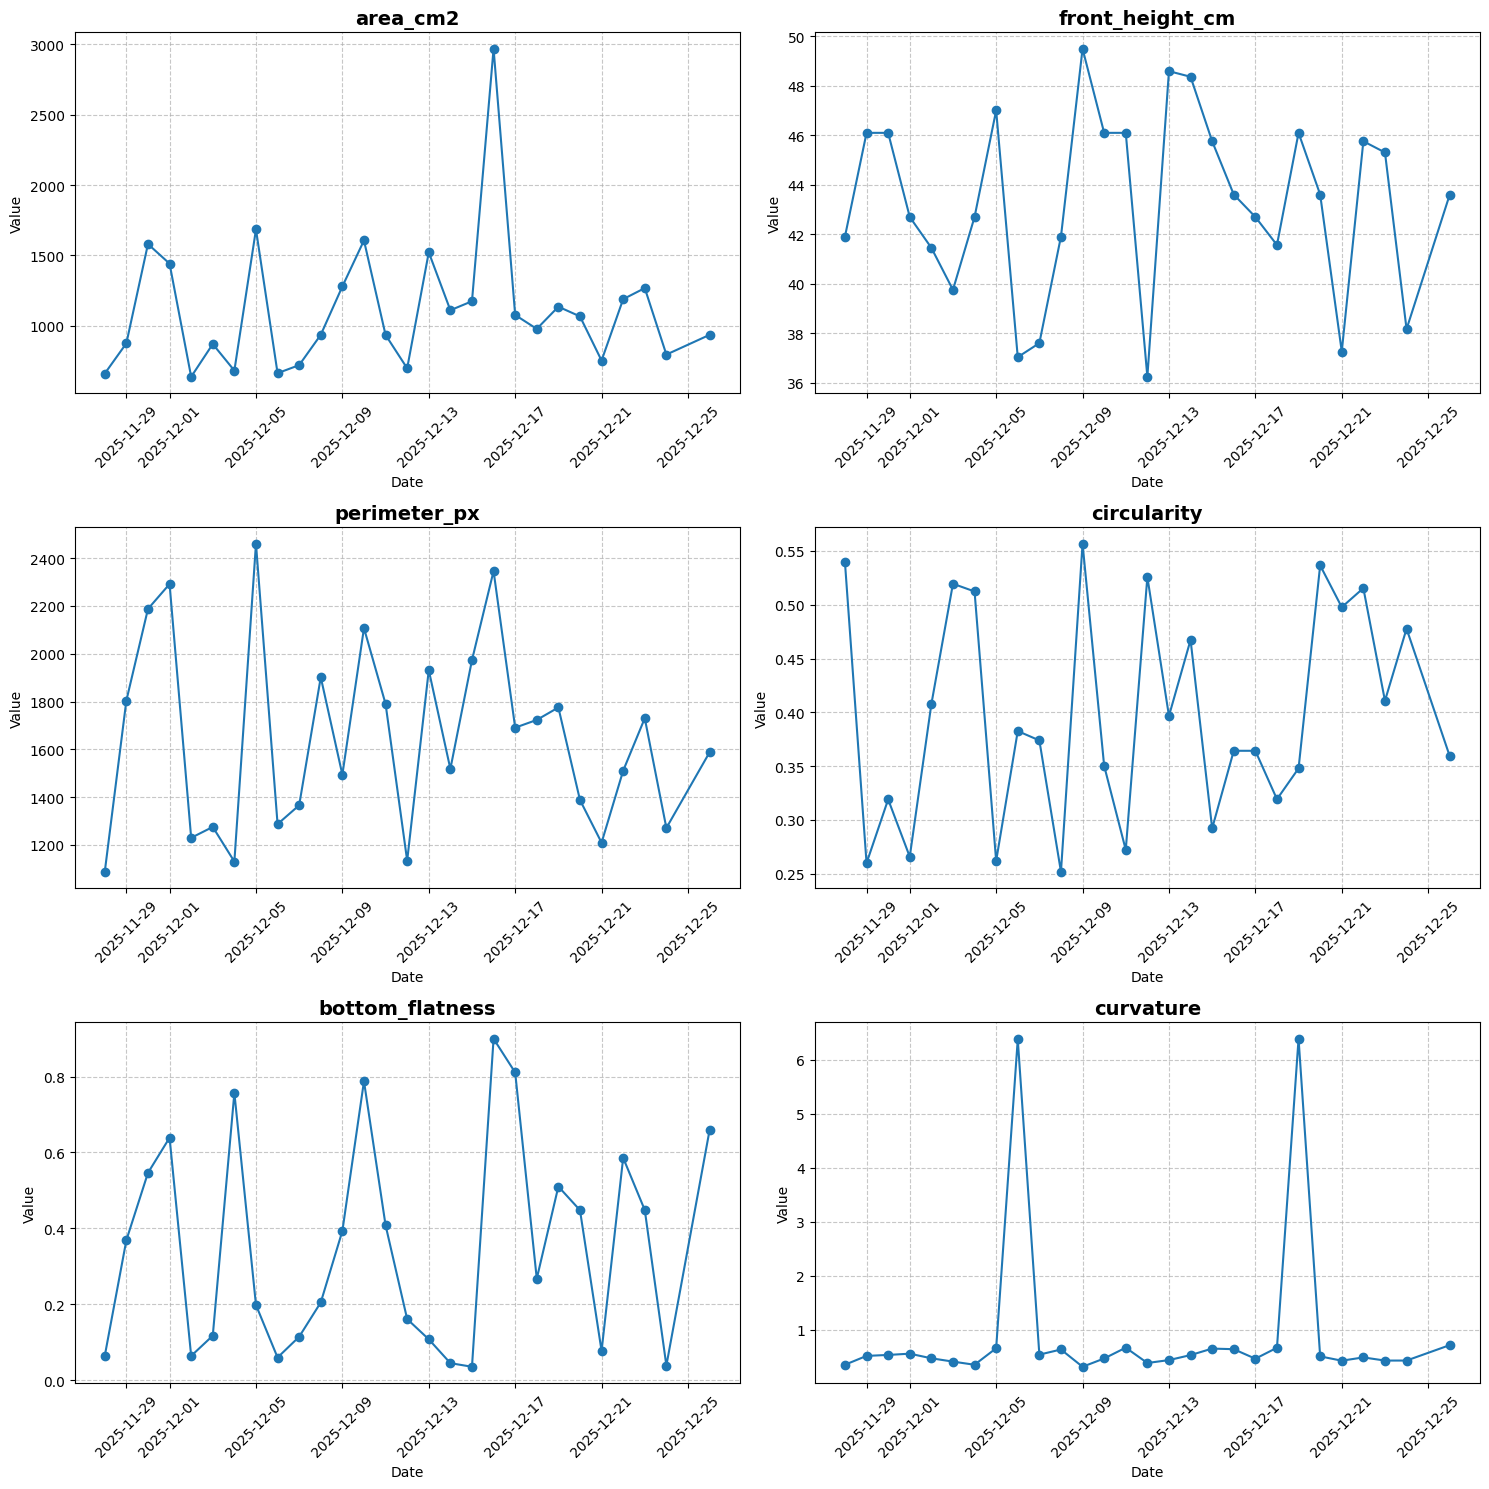

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드 (metrics 시트)
df = pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/step3_FIXED_RESULT_v2.xlsx", sheet_name='metrics')

# 2. 조건 필터링: base_key='bed02', lettuce_id='b2'
filtered_df = df[(df['base_key'] == 'bed02') & (df['lettuce_id'] == 'b4')].copy()

# 3. 날짜 형식 변환 및 정렬 (x축 시계열 표시를 위함)
filtered_df['date'] = pd.to_datetime(filtered_df['date'].astype(str), format='%Y%m%d')
filtered_df = filtered_df.sort_values('date')

# 4. 시각화할 지표 리스트
want = ['area_cm2', 'front_height_cm', 'perimeter_px', 'circularity', 'bottom_flatness', 'curvature']

# 5. 3*2 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()  # 2차원 배열을 1차원으로 변환하여 반복문 사용 용이하게 함

for i, metric in enumerate(want):
    # 꺾은선 그래프 그리기
    axes[i].plot(filtered_df['date'], filtered_df[metric], marker='o', linestyle='-', color='#1f77b4')

    # 제목 설정 (want 리스트의 항목명)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')

    # 축 설정
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')

    # x축 날짜 라벨 회전 (가독성 향상)
    axes[i].tick_params(axis='x', rotation=45)

    # 그리드 추가
    axes[i].grid(True, linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.show()

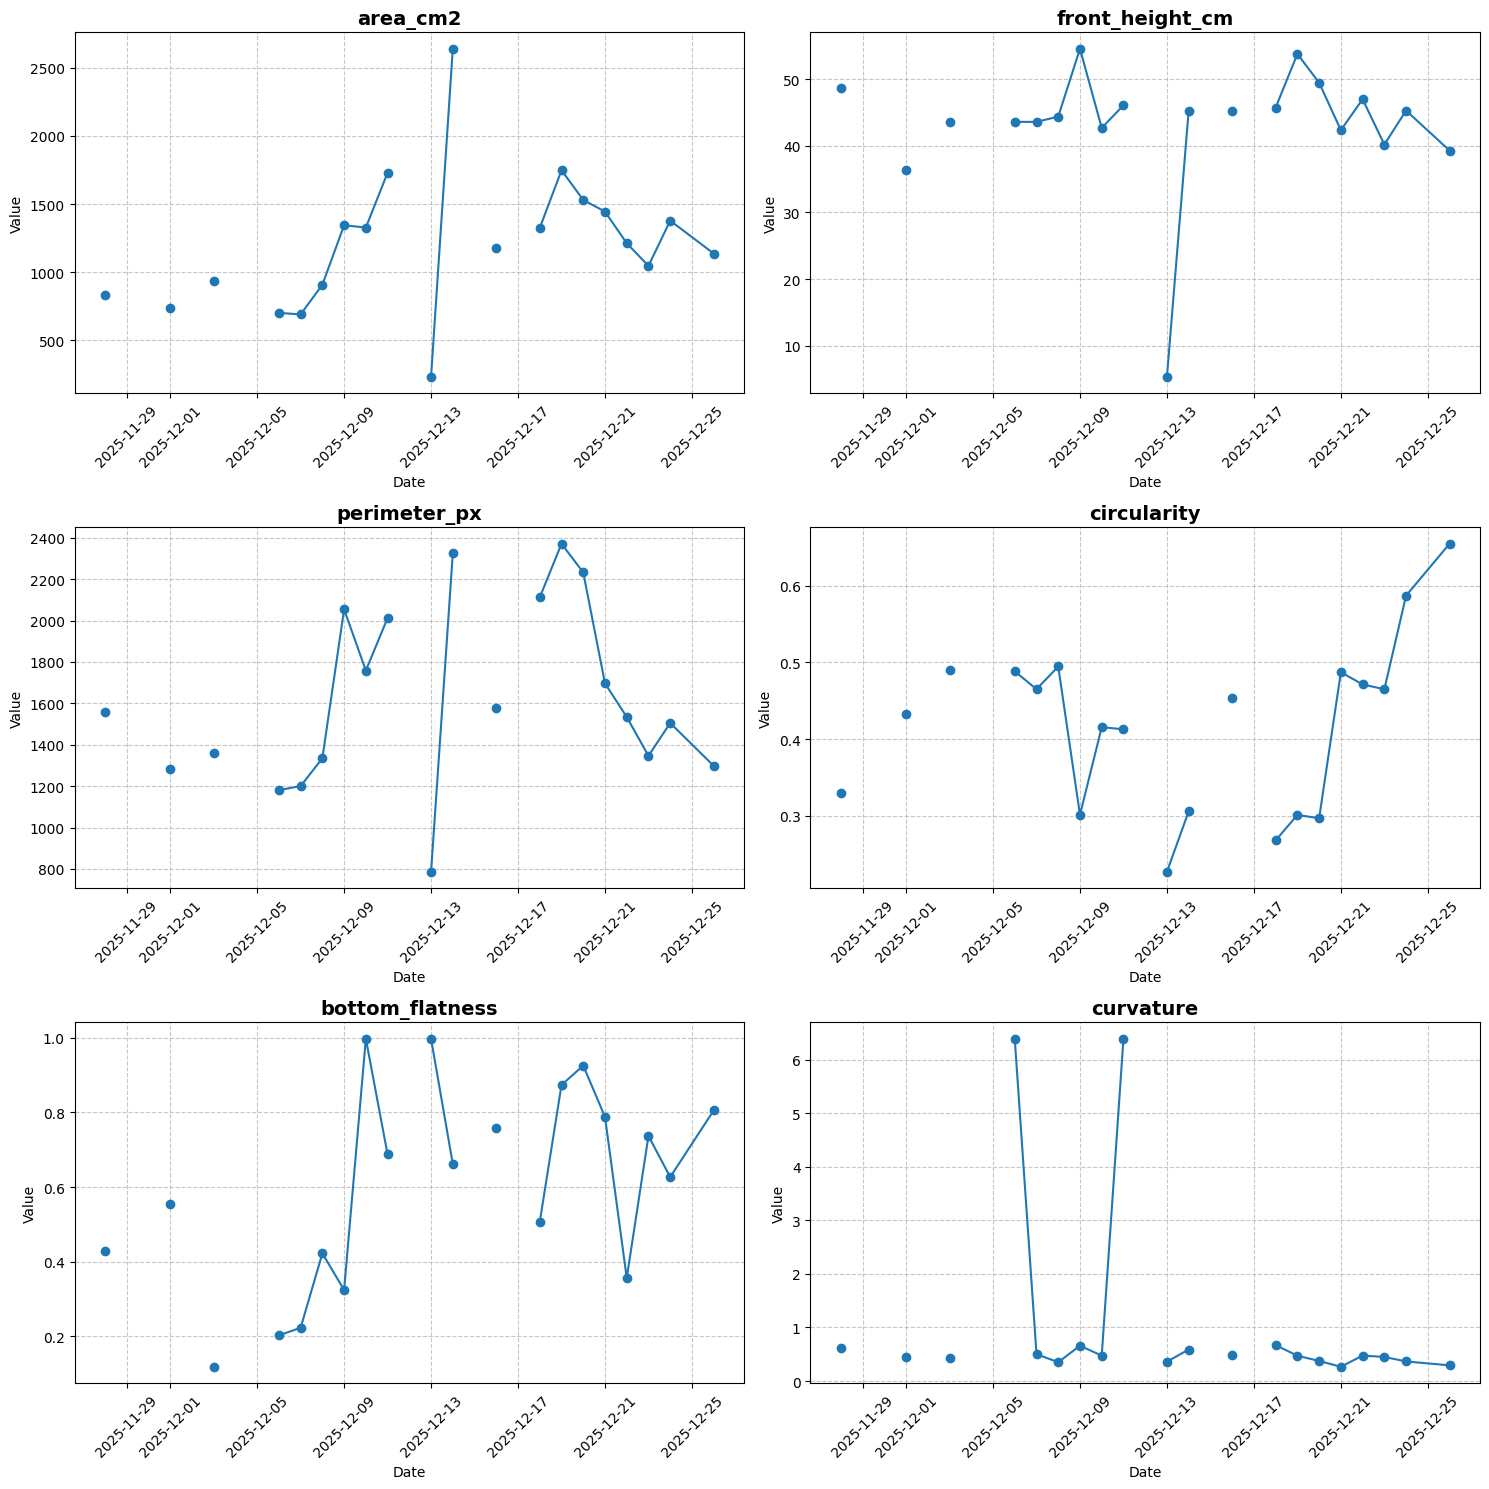

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드 (metrics 시트)
df = pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step3. lettuce/step3_FIXED_RESULT_v2.xlsx", sheet_name='metrics')

# 2. 조건 필터링: base_key='bed02', lettuce_id='b2'
filtered_df = df[(df['base_key'] == 'bed02') & (df['lettuce_id'] == 'b2')].copy()

# 3. 날짜 형식 변환 및 정렬 (x축 시계열 표시를 위함)
filtered_df['date'] = pd.to_datetime(filtered_df['date'].astype(str), format='%Y%m%d')
filtered_df = filtered_df.sort_values('date')

# 4. 시각화할 지표 리스트
want = ['area_cm2', 'front_height_cm', 'perimeter_px', 'circularity', 'bottom_flatness', 'curvature']

# 5. 3*2 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()  # 2차원 배열을 1차원으로 변환하여 반복문 사용 용이하게 함

for i, metric in enumerate(want):
    # 꺾은선 그래프 그리기
    axes[i].plot(filtered_df['date'], filtered_df[metric], marker='o', linestyle='-', color='#1f77b4')

    # 제목 설정 (want 리스트의 항목명)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')

    # 축 설정
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')

    # x축 날짜 라벨 회전 (가독성 향상)
    axes[i].tick_params(axis='x', rotation=45)

    # 그리드 추가
    axes[i].grid(True, linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.show()